<a href="https://colab.research.google.com/github/TheViet298/DogOrCat-AI/blob/main/Cat_and_Dog_Loss_Binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#import package
import os
import shutil
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

import tensorflow as tf
import zipfile
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
#Tạo lớp folder
dataset_dir = '/content/drive/MyDrive/DogOrCat-main/dogs-vs-cats/train/'
output_dir = '/content/drive/MyDrive/DogOrCat-main/dogs-vs-cats/train'

os.makedirs(os.path.join(output_dir, 'cat'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'dog'), exist_ok=True)

for filename in os.listdir(dataset_dir):
    if filename.endswith('.jpg'):
        if 'cat' in filename.lower():
            shutil.move(os.path.join(dataset_dir, filename), os.path.join(output_dir, 'cat', filename))
        elif 'dog' in filename.lower():
            shutil.move(os.path.join(dataset_dir, filename), os.path.join(output_dir, 'dog', filename))

In [13]:
#Định nghĩa thư mục sau giải nén
dataset_dir = os.path.join('/content/drive/MyDrive/DogOrCat-main/dogs-vs-cats/train')

#Tạo ImageDataGenerator cho training and validation
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

#training
train_generator = train_datagen.flow_from_directory(dataset_dir,target_size=(128, 128),
    batch_size=16,class_mode='binary',subset='training')

#validation
validation_generator = train_datagen.flow_from_directory(dataset_dir,target_size=(128, 128),
    batch_size=16,class_mode='binary',subset='validation')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


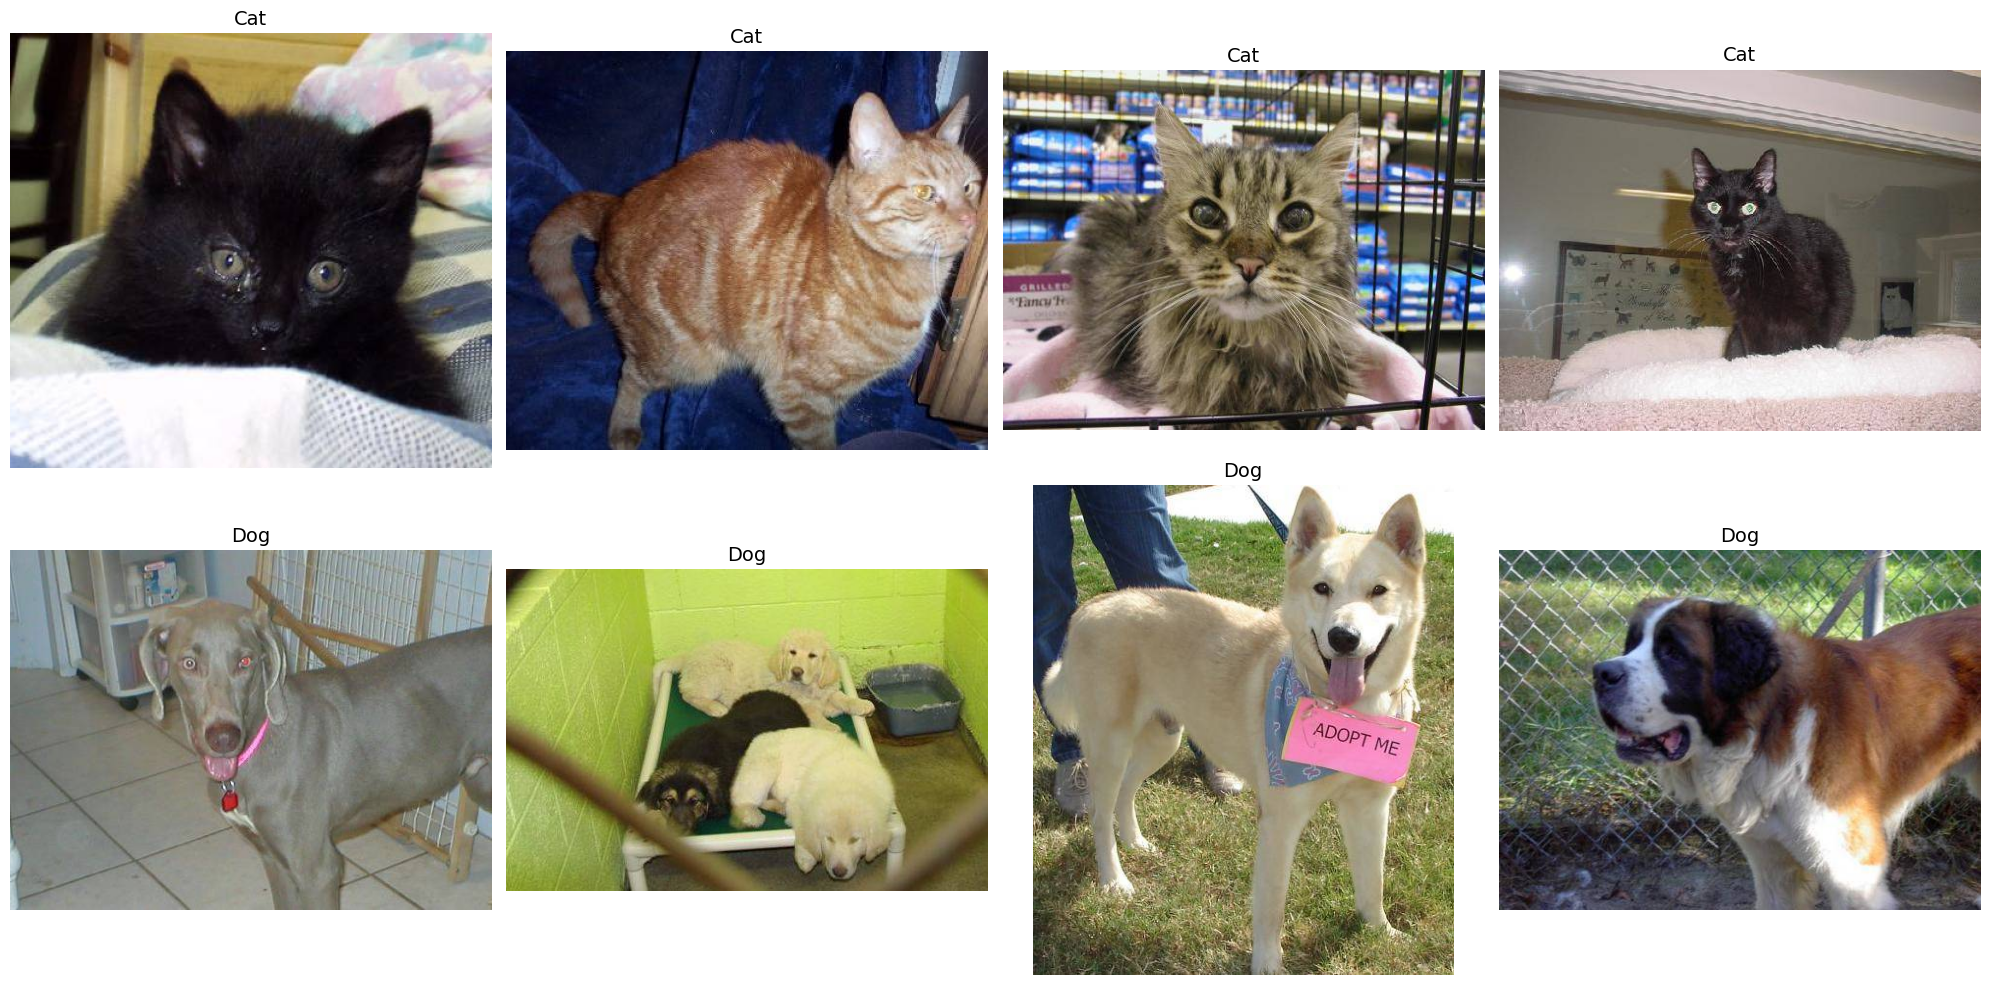

In [4]:
#HIển thị 4 ảnh mỗi lớp
cat_images = []
dog_images = []

for filename, label in zip(train_generator.filenames, train_generator.labels):
    img_path = os.path.join(train_generator.directory, filename)
    if label == 0:
        cat_images.append(img_path)
    elif label == 1:
        dog_images.append(img_path)
    if len(cat_images) >= 4 and len(dog_images) >= 4:
        break

images_to_display = cat_images[:4] + dog_images[:4]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, ax in enumerate(axes.flatten()):
    img = image.load_img(images_to_display[i])
    ax.imshow(img)
    ax.axis('off')
    if i < 4:
        ax.set_title("Cat", fontsize=14)
    else:
        ax.set_title("Dog", fontsize=14)
plt.tight_layout()
plt.show()

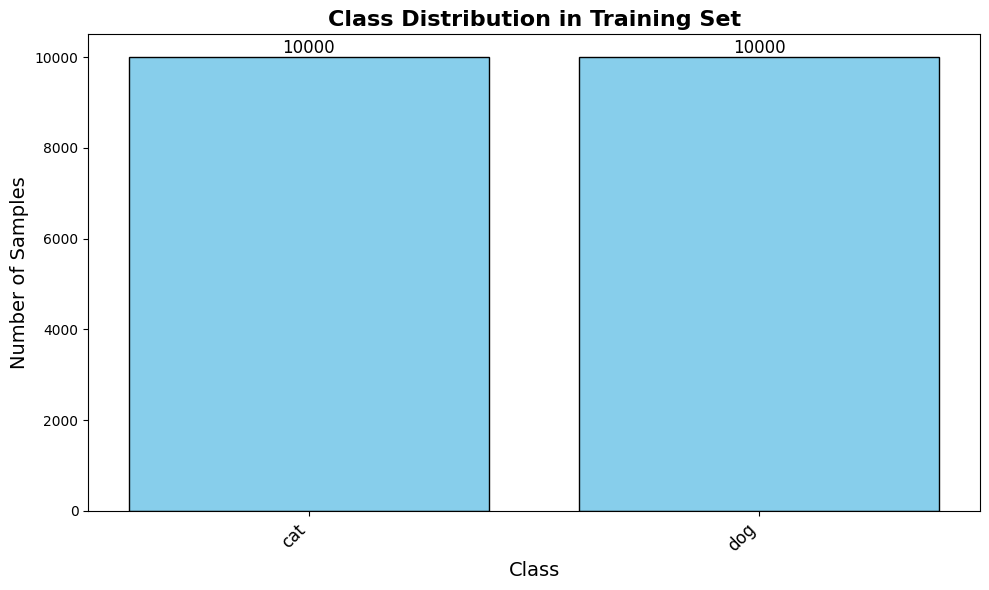

In [5]:
#Phân bố lớp

class_labels = list(train_generator.class_indices.keys())
train_class_counts = [list(train_generator.labels).count(i) for i in range(len(class_labels))]

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(class_labels, train_class_counts, color='skyblue', edgecolor='black')


# Hiển thị số lượng mẫu trên các cột
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=12)
plt.title('Class Distribution in Training Set', fontsize=16, fontweight='bold')
plt.xlabel('Class', fontsize=14)
plt.ylabel('Number of Samples', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

Huấn luyện mô hình

In [14]:
from tensorflow.keras.layers import BatchNormalization

# Hàm khởi tạo mô hình CNN
def cnn_model():
    model = Sequential()
    # Lớp tích chập đầu tiên + ReLU + MaxPooling
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Lớp tích chập thứ hai + ReLU + MaxPooling
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(70, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Biên dịch mô hình với optimizer Adam và loss nhị phân
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Huấn luyện mô hình
custom_cnn_model = cnn_model()

history = custom_cnn_model.fit(
    train_generator,                # Dữ liệu huấn luyện
    validation_data=validation_generator,  # Dữ liệu kiểm tra
    epochs=5,                       # Số vòng lặp huấn luyện
    verbose=1                       # Hiển thị tiến trình huấn luyện
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4027s 3s/step - accuracy: 0.5464 - loss: 0.9787 - val_accuracy: 0.6840 - val_loss: 0.6231
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 134s 107ms/step - accuracy: 0.7367 - loss: 0.5219 - val_accuracy: 0.7620 - val_loss: 0.5163
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 131s 105ms/step - accuracy: 0.8026 - loss: 0.4060 - val_accuracy: 0.7822 - val_loss: 0.4723
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 113s 91ms/step - accuracy: 0.8470 - loss: 0.3322 - val_accuracy: 0.7624 - val_loss: 0.5427
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 111s 89ms/step - accuracy: 0.8790 - loss: 0.2658 - val_accuracy: 0.7660 - val_loss: 0.5516


In [15]:
#making predictions on some sample data
sample_images, sample_labels = next(validation_generator)
predictions = custom_cnn_model.predict(sample_images)
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step


In [16]:
custom_cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 70)             │     4,032,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            71 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,155,369 (46.37 MB)

 Trainable params: 4,051,725 (15.46 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 8,103,452 (30.91 MB)

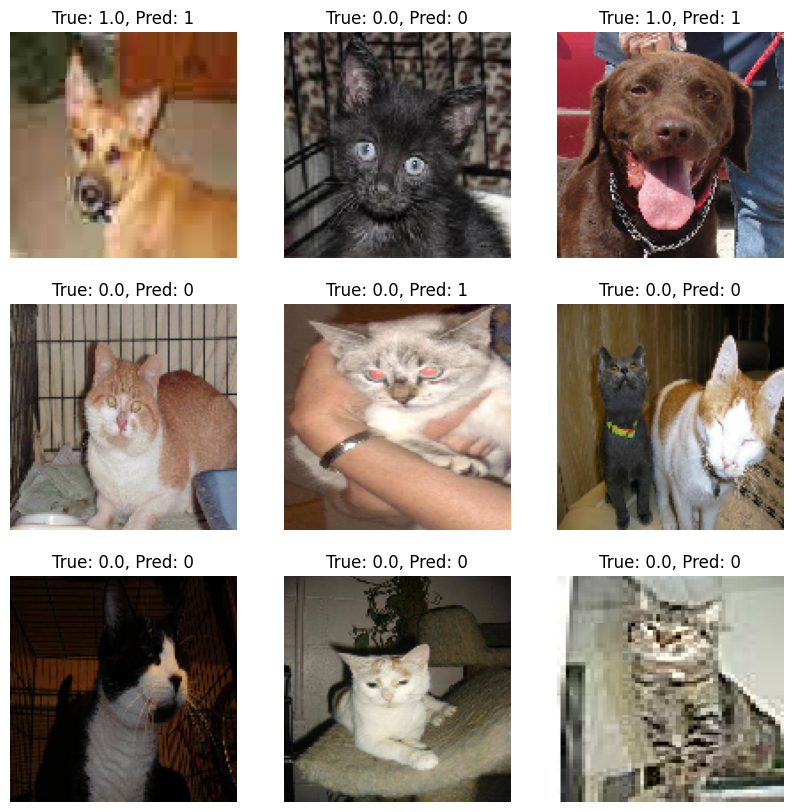

In [18]:
#Hiển thị ảnh và dự đoán mẫu
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    plt.title(f'True: {sample_labels[i]}, Pred: {predicted_labels[i]}')
    plt.axis('off')
plt.show()

In [19]:
#classification report
y_true_classes = sample_labels
y_pred_classes = predicted_labels
print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.80      0.80        10
         1.0       0.67      0.67      0.67         6

    accuracy                           0.75        16
   macro avg       0.73      0.73      0.73        16
weighted avg       0.75      0.75      0.75        16



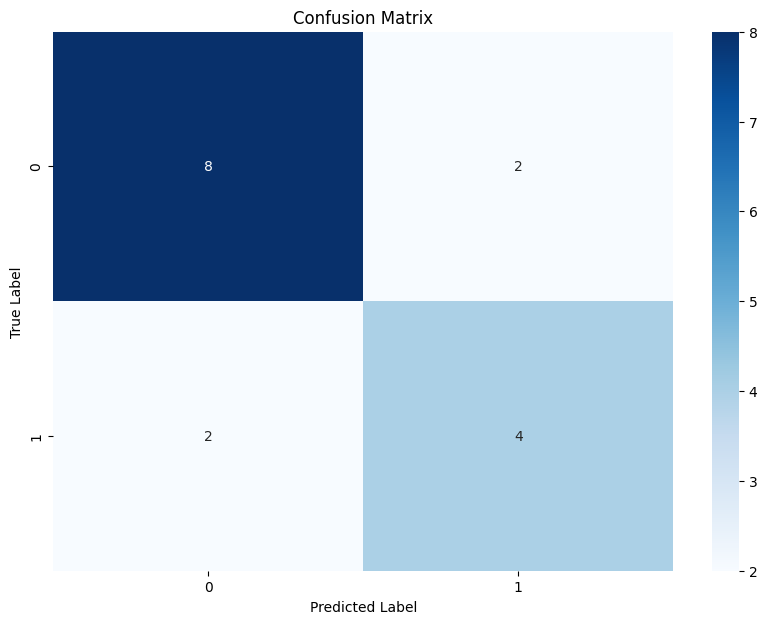

In [20]:
#show ma trận confusion
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(2), yticklabels=np.arange(2))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


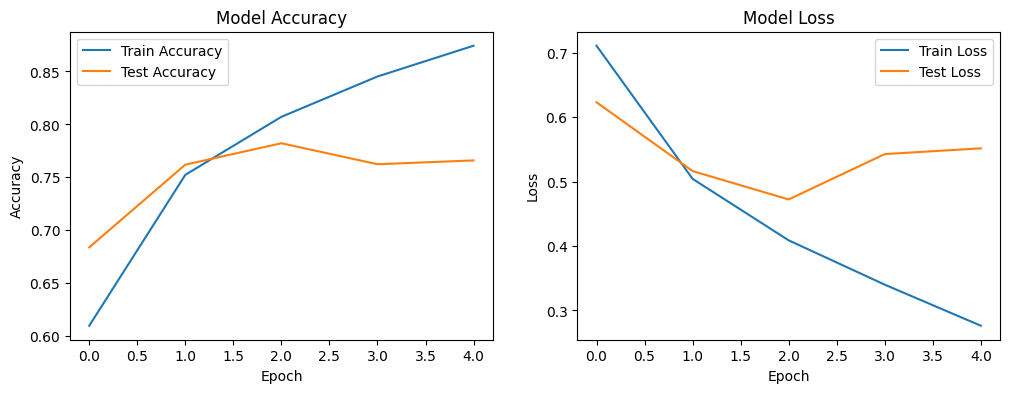

In [21]:
#Vẽ biểu đồ accurary
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
#Vẽ biểu đồ loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [23]:
# lưu mô hình
custom_cnn_model.save("cats_vs_dogs_cnn_model.keras")

In [26]:
from google.colab import files
files.download('cats_vs_dogs_cnn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>